<a href="https://colab.research.google.com/github/musowjanya/Datascience-Project/blob/main/L2T2_price_range_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("/content/Dataset .csv")

print(df.columns)
print(df.head())

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chin

Most Common Price Range


Most Common Price Range: 1


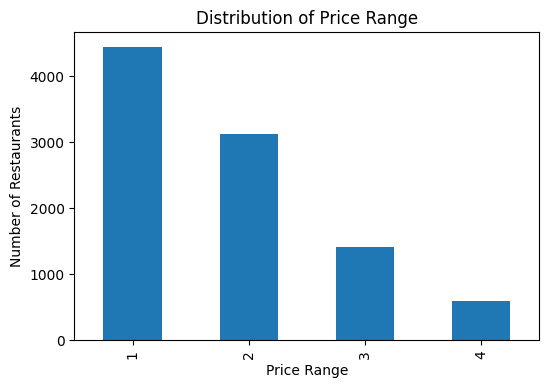

In [22]:
most_common_price = df["Price range"].mode()[0]
print(f"\nMost Common Price Range: {most_common_price}")

# Visualization
plt.figure(figsize=(6,4))
df["Price range"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

Average rating per Price Range


Average Rating for Each Price Range:
 Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


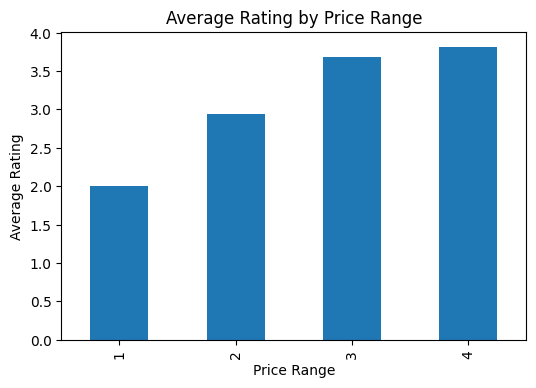

In [23]:
avg_rating_price = df.groupby("Price range")["Aggregate rating"].mean()

print("\nAverage Rating for Each Price Range:\n", avg_rating_price)

# Plot
plt.figure(figsize=(6,4))
avg_rating_price.plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()


Highest Rating

In [24]:
# Group by both price range and rating color
color_rating = df.groupby(["Price range", "Rating color"])["Aggregate rating"].mean().reset_index()

print("\nAverage Rating by Price Range and Color:\n", color_rating)

# Find highest rating row
highest_rating_row = color_rating.loc[color_rating["Aggregate rating"].idxmax()]

print("\nColor Representing Highest Average Rating:")
print(highest_rating_row)


Average Rating by Price Range and Color:
     Price range Rating color  Aggregate rating
0             1   Dark Green          4.668750
1             1        Green          4.157639
2             1       Orange          3.040464
3             1          Red          2.293548
4             1        White          0.000000
5             1       Yellow          3.661842
6             2   Dark Green          4.627536
7             2        Green          4.159385
8             2       Orange          3.048491
9             2          Red          2.300000
10            2        White          0.000000
11            2       Yellow          3.671159
12            3   Dark Green          4.646032
13            3        Green          4.169231
14            3       Orange          3.097764
15            3          Red          2.305000
16            3        White          0.000000
17            3       Yellow          3.716265
18            4   Dark Green          4.709459
19            4  

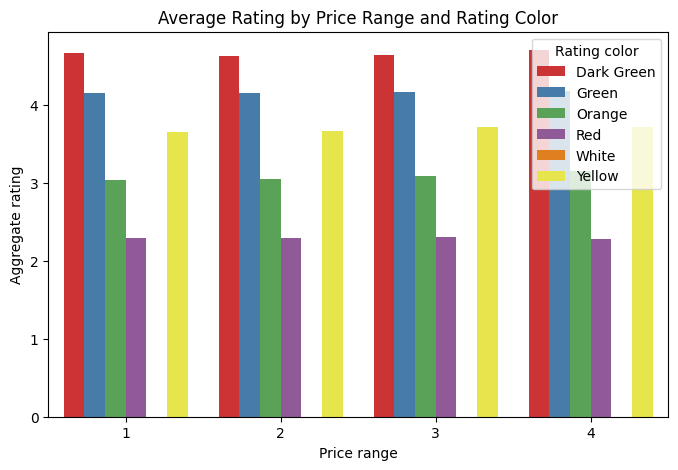

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=color_rating, x="Price range", y="Aggregate rating", hue="Rating color", palette="Set1")
plt.title("Average Rating by Price Range and Rating Color")
plt.show()


Overall Average Rating by Color:
 Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
Orange        3.051619
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64


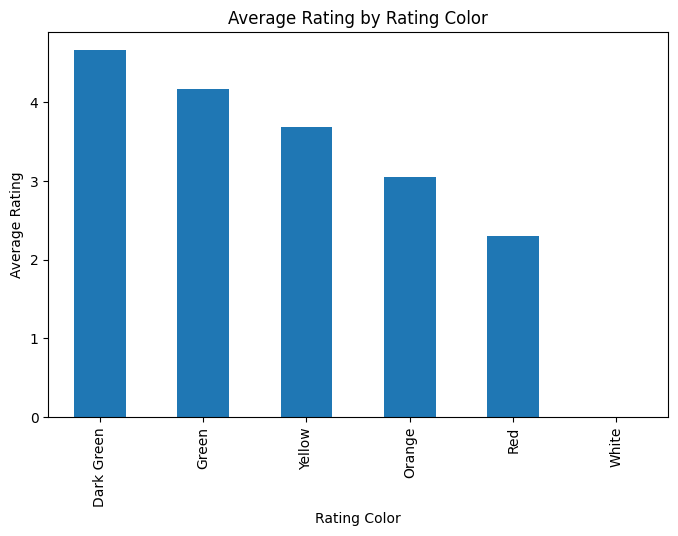

In [26]:
# Which color overall has highest rating
overall_color_rating = df.groupby("Rating color")["Aggregate rating"].mean().sort_values(ascending=False)

print("\nOverall Average Rating by Color:\n", overall_color_rating)

# Plot
plt.figure(figsize=(8,5))
overall_color_rating.plot(kind='bar')
plt.title("Average Rating by Rating Color")
plt.xlabel("Rating Color")
plt.ylabel("Average Rating")
plt.show()